# Flagging Vendor Invoices for Manual Review

**Objective:** Predict whether a vendor invoice should be flagged for manual approval based on abnormal cost, freight, or delivery patterns, in order to reduce financial risk, improve operational efficiency, and prioritize human review where it adds the most value.

- Manual invoice review is time-consuming and does not scale with transaction volume.
- Abnormal freight charges, pricing deviations, or delivery delays often indicate errors, disputes, or compliance risks.
- An automated flagging system enables finance teams to focus attention on high-risk invoices while allowing low-risk invoices to be processed automatically.

In [46]:
import sqlite3
import pandas as pd
import seaborn as sns
from scipy.stats import ttest_ind
import matplotlib.pyplot as plt

In [47]:
conn=sqlite3.connect("/Users/shyamchauhan/Desktop/home/codes/project/vendor_invoice_intelligence_portal/data/inventory.db")
tables=pd.read_sql_query("select name from sqlite_master where type='table'",conn)

In [48]:
for table in tables['name']:
    print('table name :',table)
    df=pd.read_sql_query(f"select * from {table} limit 5 ",conn)
    # display (df.dtypes)
    display (df)

table name : purchases


,InventoryId,Store,Brand,Description,Size,VendorNumber,VendorName,PONumber,PODate,ReceivingDate,InvoiceDate,PayDate,PurchasePrice,Quantity,Dollars,Classification
0,69_MOUNTMEND_8412,69,8412,Tequila Ocho Plata Fresno,750mL,105,ALTAMAR BRANDS LLC,8124,2023-12-21,2024-01-02,2024-01-04,2024-02-16,35.71,6,214.26,1
1,30_CULCHETH_5255,30,5255,TGI Fridays Ultimte Mudslide,1.75L,4466,AMERICAN VINTAGE BEVERAGE,8137,2023-12-22,2024-01-01,2024-01-07,2024-02-21,9.35,4,37.40,1
2,34_PITMERDEN_5215,34,5215,TGI Fridays Long Island Iced,1.75L,4466,AMERICAN VINTAGE BEVERAGE,8137,2023-12-22,2024-01-02,2024-01-07,2024-02-21,9.41,5,47.05,1
3,1_HARDERSFIELD_5255,1,5255,TGI Fridays Ultimte Mudslide,1.75L,4466,AMERICAN VINTAGE BEVERAGE,8137,2023-12-22,2024-01-01,2024-01-07,2024-02-21,9.35,6,56.10,1
4,76_DONCASTER_2034,76,2034,Glendalough Double Barrel,750mL,388,ATLANTIC IMPORTING COMPANY,8169,2023-12-24,2024-01-02,2024-01-09,2024-02-16,21.32,5,106.60,1


table name : purchase_prices


,Brand,Description,Price,Size,Volume,Classification,PurchasePrice,VendorNumber,VendorName
0,58,Gekkeikan Black & Gold Sake,12.99,750mL,750,1,9.28,8320,SHAW ROSS INT L IMP LTD
1,62,Herradura Silver Tequila,36.99,750mL,750,1,28.67,1128,BROWN-FORMAN CORP
2,63,Herradura Reposado Tequila,38.99,750mL,750,1,30.46,1128,BROWN-FORMAN CORP
3,72,No. 3 London Dry Gin,34.99,750mL,750,1,26.11,9165,ULTRA BEVERAGE COMPANY LLP
4,75,Three Olives Tomato Vodka,14.99,750mL,750,1,10.94,7245,PROXIMO SPIRITS INC.


table name : vendor_invoice


,VendorNumber,VendorName,InvoiceDate,PONumber,PODate,PayDate,Quantity,Dollars,Freight,Approval
0,105,ALTAMAR BRANDS LLC,2024-01-04,8124,2023-12-21,2024-02-16,6,214.26,3.47,None
1,4466,AMERICAN VINTAGE BEVERAGE,2024-01-07,8137,2023-12-22,2024-02-21,15,140.55,8.57,None
2,388,ATLANTIC IMPORTING COMPANY,2024-01-09,8169,2023-12-24,2024-02-16,5,106.60,4.61,None
3,480,BACARDI USA INC,2024-01-12,8106,2023-12-20,2024-02-05,10100,137483.78,2935.20,None
4,516,BANFI PRODUCTS CORP,2024-01-07,8170,2023-12-24,2024-02-12,1935,15527.25,429.20,None


table name : begin_inventory


,InventoryId,Store,City,Brand,Description,Size,onHand,Price,startDate
0,1_HARDERSFIELD_58,1,HARDERSFIELD,58,Gekkeikan Black & Gold Sake,750mL,8,12.99,2024-01-01
1,1_HARDERSFIELD_60,1,HARDERSFIELD,60,Canadian Club 1858 VAP,750mL,7,10.99,2024-01-01
2,1_HARDERSFIELD_62,1,HARDERSFIELD,62,Herradura Silver Tequila,750mL,6,36.99,2024-01-01
3,1_HARDERSFIELD_63,1,HARDERSFIELD,63,Herradura Reposado Tequila,750mL,3,38.99,2024-01-01
4,1_HARDERSFIELD_72,1,HARDERSFIELD,72,No. 3 London Dry Gin,750mL,6,34.99,2024-01-01


table name : end_inventory


,InventoryId,Store,City,Brand,Description,Size,onHand,Price,endDate
0,1_HARDERSFIELD_58,1,HARDERSFIELD,58,Gekkeikan Black & Gold Sake,750mL,11,12.99,2024-12-31
1,1_HARDERSFIELD_62,1,HARDERSFIELD,62,Herradura Silver Tequila,750mL,7,36.99,2024-12-31
2,1_HARDERSFIELD_63,1,HARDERSFIELD,63,Herradura Reposado Tequila,750mL,7,38.99,2024-12-31
3,1_HARDERSFIELD_72,1,HARDERSFIELD,72,No. 3 London Dry Gin,750mL,4,34.99,2024-12-31
4,1_HARDERSFIELD_75,1,HARDERSFIELD,75,Three Olives Tomato Vodka,750mL,7,14.99,2024-12-31


In [49]:
purchase_agg_data=pd.read_sql_query("""
select
p.PONumber,
count(distinct p.Brand) as total_brands,
sum(p.Quantity) as total_item_quantity,
sum(p.dollars) as total_item_dollars,
avg(julianday(p.ReceivingDate)-julianday(p.PODate)) as avg_receiving_delay

from purchases as p
group by p.PONumber

""",conn)

In [50]:
purchase_agg_data

,PONumber,total_brands,total_item_quantity,total_item_dollars,avg_receiving_delay
0,8106,81,10100,137483.78,12.614130
1,8107,2,24,348.72,12.500000
2,8108,165,8466,60281.13,12.632479
3,8109,23,2246,14298.09,12.626866
4,8110,183,8086,56493.23,12.695271
...,...,...,...,...,...
5538,13657,3,253,3844.39,4.870968
5539,13658,111,14115,102949.38,5.016349
5540,13659,13,338,2492.20,4.735294
5541,13660,12,195,2599.66,4.611111


In [51]:
df = pd.read_sql_query("""
-- Aggregate purchase data
WITH purchase_agg AS (
    SELECT
        p.PONumber,
        COUNT(DISTINCT p.Brand) AS total_brands,
        SUM(p.Quantity) AS total_item_quantity,
        SUM(p.Dollars) AS total_item_dollars,
        AVG(julianday(p.ReceivingDate) - julianday(p.PODate)) AS avg_receiving_delay
    FROM purchases p
    GROUP BY p.PONumber
)

-- Join with vendor invoices
SELECT
    vi.PONumber,
    vi.Quantity AS invoice_quantity,
    vi.Dollars AS invoice_dollars,
    vi.Freight,
    (julianday(vi.InvoiceDate) - julianday(vi.PODate)) AS days_po_to_invoice,
    (julianday(vi.PayDate) - julianday(vi.InvoiceDate)) AS days_to_pay,
    pa.total_brands,
    pa.total_item_quantity,
    pa.total_item_dollars,
    pa.avg_receiving_delay
FROM vendor_invoice vi
LEFT JOIN purchase_agg pa
    ON vi.PONumber = pa.PONumber
""", conn)

In [52]:
print(df.isnull().sum())
df.dtypes

PONumber               0
invoice_quantity       0
invoice_dollars        0
Freight                0
days_po_to_invoice     0
days_to_pay            0
total_brands           0
total_item_quantity    0
total_item_dollars     0
avg_receiving_delay    0
dtype: int64


PONumber                 int64
invoice_quantity         int64
invoice_dollars        float64
Freight                float64
days_po_to_invoice     float64
days_to_pay            float64
total_brands             int64
total_item_quantity      int64
total_item_dollars     float64
avg_receiving_delay    float64
dtype: object

In [53]:
df.head(5)

,PONumber,invoice_quantity,invoice_dollars,Freight,days_po_to_invoice,days_to_pay,total_brands,total_item_quantity,total_item_dollars,avg_receiving_delay
0,8124,6,214.26,3.47,14.0,43.0,1,6,214.26,12.000000
1,8137,15,140.55,8.57,16.0,45.0,2,15,140.55,10.333333
2,8169,5,106.60,4.61,16.0,38.0,1,5,106.60,9.000000
3,8106,10100,137483.78,2935.20,23.0,24.0,81,10100,137483.78,12.614130
4,8170,1935,15527.25,429.20,14.0,36.0,29,1935,15527.25,8.752809


In [54]:
# does invoice require manual approval or not
def create_invoice_risk_label(row):
    # Invoice total mismatch with item-level total
    # require manual approval if total items cost does not match with invoice invoice cost
    if abs(row["invoice_dollars"] - row["total_item_dollars"]) > 5:
        return 1

    # Abnormally high receiving delay
    if row["avg_receiving_delay"] > 10:
        return 1
    return 0

df["flag_invoice"] = df.apply(create_invoice_risk_label, axis=1)
df["flag_invoice"].value_counts()

flag_invoice
0    3693
1    1850
Name: count, dtype: int64

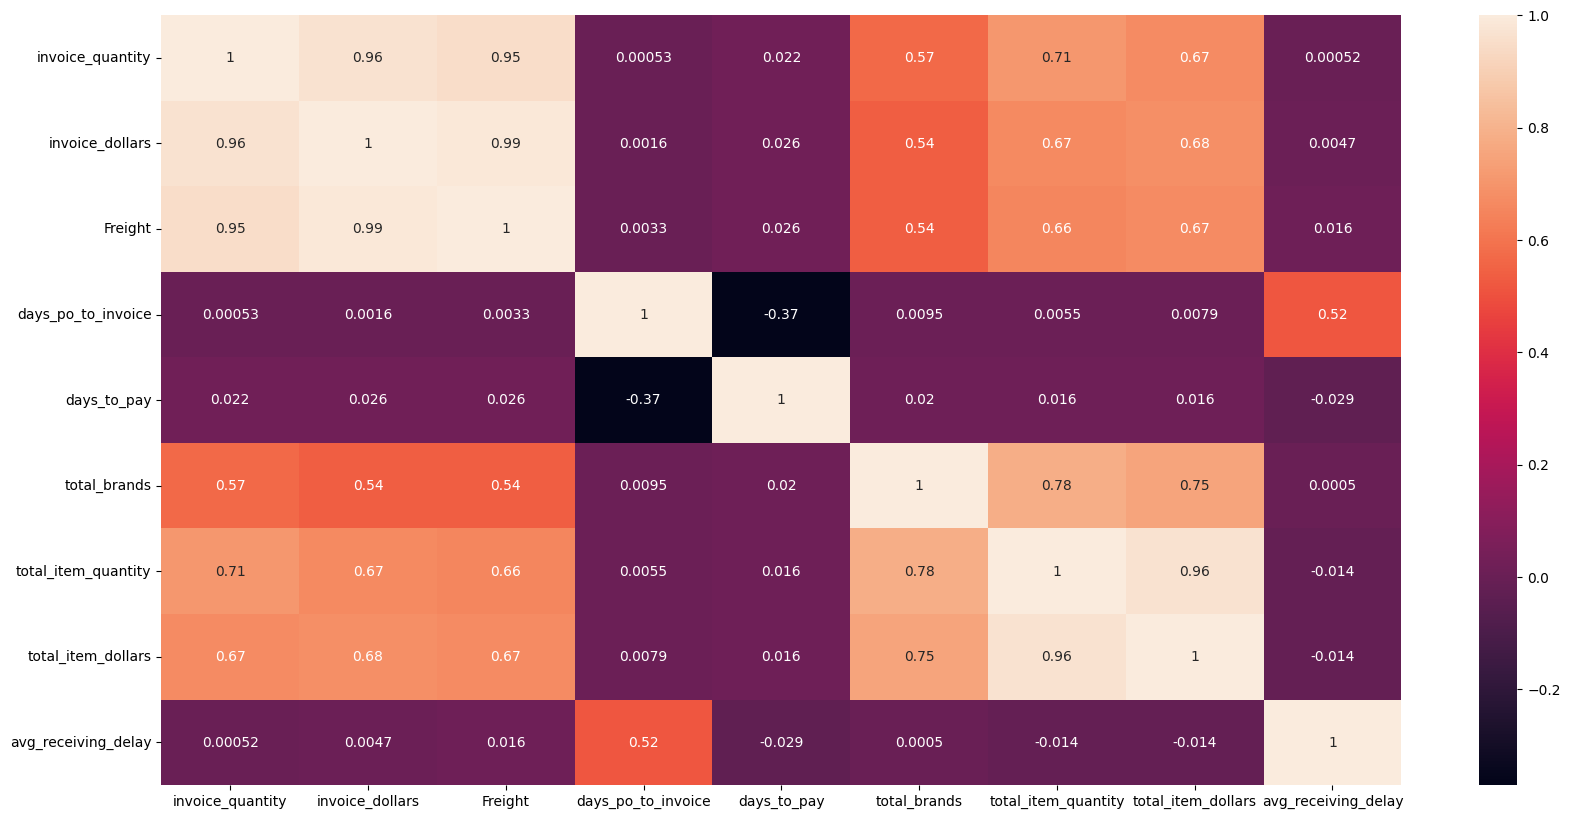

In [55]:
plt.figure(figsize=(20,10))
sns.heatmap(df.iloc[:,1:-1].corr(),annot=True)
plt.show()

In [56]:
flagged=df[df['flag_invoice']==1]
normal=df[df['flag_invoice']==0]

In [57]:
# t test is used when mean and sd is unknown and we need to check if there is signnificant difference
significant_features=[]
non_significant_features=[]
results=[]

In [58]:
metrics = [
    'invoice_quantity',
    'invoice_dollars',
    'Freight',
    'days_po_to_invoice',
    'days_to_pay',
    'total_brands',
    'total_item_quantity',
    'total_item_dollars',
    'avg_receiving_delay'
]

In [59]:
'''
significant difference means observed difference is unlikely to have happened by chance ... likely reflects real difference between groups.
p_value < 0.05 ==> there is significant difference
p_value > 0.05 ==> no significant difference
'''
for metric in metrics:
    flagged_mean=flagged[metric].mean()
    normal_mean=normal[metric].mean()

    t_stats,p_value=ttest_ind(
        flagged[metric].dropna(),
        normal[metric].dropna(),
        equal_var=False
    )
    if p_value<0.05:
        significant_features.append(metric)
        results.append({
            "metric":metric,
            "flagged_mean":float(flagged_mean.round(2)),
            "normal_mean":float(normal_mean.round(2)),
            "p_value":float(p_value.round(3))
        })
    else:
        non_significant_features.append(metric)
        print(metric)
        print({
            "metric":metric,
            "flagged_mean":float(flagged_mean.round(2)),
            "normal_mean":float(normal_mean.round(2)),
            "p_value":float(p_value.round(3))
        })

days_to_pay
{'metric': 'days_to_pay', 'flagged_mean': 35.42, 'normal_mean': 35.49, 'p_value': 0.692}
total_brands
{'metric': 'total_brands', 'flagged_mean': 42.29, 'normal_mean': 40.82, 'p_value': 0.508}


In [60]:
non_significant_features

['days_to_pay', 'total_brands']

In [61]:
significant_features

['invoice_quantity',
 'invoice_dollars',
 'Freight',
 'days_po_to_invoice',
 'total_item_quantity',
 'total_item_dollars',
 'avg_receiving_delay']

In [62]:
results

[{'metric': 'invoice_quantity',
  'flagged_mean': 6728.28,
  'normal_mean': 5723.55,
  'p_value': 0.021},
 {'metric': 'invoice_dollars',
  'flagged_mean': 65600.61,
  'normal_mean': 54302.64,
  'p_value': 0.008},
 {'metric': 'Freight',
  'flagged_mean': 334.02,
  'normal_mean': 276.89,
  'p_value': 0.008},
 {'metric': 'days_po_to_invoice',
  'flagged_mean': 17.23,
  'normal_mean': 16.02,
  'p_value': 0.0},
 {'metric': 'total_item_quantity',
  'flagged_mean': 6728.28,
  'normal_mean': 5723.55,
  'p_value': 0.021},
 {'metric': 'total_item_dollars',
  'flagged_mean': 65600.61,
  'normal_mean': 54302.64,
  'p_value': 0.008},
 {'metric': 'avg_receiving_delay',
  'flagged_mean': 8.47,
  'normal_mean': 7.27,
  'p_value': 0.0}]

In [63]:
X = df[['invoice_quantity', 'invoice_dollars', 'Freight',
        'total_brands', 'total_item_quantity',
        'days_po_to_invoice', 'total_item_dollars']]

y = df['flag_invoice']

In [64]:
X.describe().round()

,invoice_quantity,invoice_dollars,Freight,total_brands,total_item_quantity,days_po_to_invoice,total_item_dollars
count,5543.0,5543.0,5543.0,5543.0,5543.0,5543.0,5543.0
mean,6059.0,58073.0,296.0,41.0,6059.0,16.0,58073.0
std,14453.0,140234.0,714.0,77.0,14453.0,3.0,140234.0
min,1.0,4.0,0.0,1.0,1.0,9.0,4.0
25%,83.0,968.0,5.0,3.0,83.0,14.0,968.0
50%,423.0,4765.0,25.0,7.0,423.0,16.0,4765.0
75%,5100.0,44587.0,230.0,46.0,5100.0,19.0,44587.0
max,141660.0,1660436.0,8468.0,807.0,141660.0,23.0,1660436.0


In [65]:
from sklearn.preprocessing import StandardScaler,MinMaxScaler
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)
scaler=MinMaxScaler()
x_trained_scaled=scaler.fit_transform(X_train)
x_test_scaled=scaler.transform(X_test)

In [66]:
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier


In [67]:
# Logistic Regression
model1 = LogisticRegression(random_state=42)
model1.fit(x_trained_scaled, y_train)

# Decision Tree
model2 = DecisionTreeClassifier(random_state=42)
model2.fit(x_trained_scaled, y_train)

# Random Forest
model3 = RandomForestClassifier(random_state=42)
model3.fit(x_trained_scaled, y_train)

RandomForestClassifier(random_state=42)

In [68]:
from sklearn.metrics import accuracy_score, classification_report

def evaluate_model(model, X_test, y_test, model_name):
    y_pred = model.predict(X_test)
    acc = accuracy_score(y_test, y_pred)
    print(f"\n{model_name}")
    print(f"Accuracy: {acc:.2f}") 
    print(classification_report(y_test, y_pred))


In [69]:
evaluate_model(model1,x_test_scaled,y_test,'Logistic regression')
evaluate_model(model2, x_test_scaled, y_test, 'Decision Tree Classifier')
evaluate_model(model3, x_test_scaled, y_test, 'Random Forest Classifier')


Logistic regression
Accuracy: 0.66
              precision    recall  f1-score   support

           0       0.66      0.98      0.79       725
           1       0.58      0.06      0.10       384

    accuracy                           0.66      1109
   macro avg       0.62      0.52      0.45      1109
weighted avg       0.63      0.66      0.55      1109


Decision Tree Classifier
Accuracy: 0.81
              precision    recall  f1-score   support

           0       0.85      0.87      0.86       725
           1       0.74      0.71      0.73       384

    accuracy                           0.81      1109
   macro avg       0.80      0.79      0.79      1109
weighted avg       0.81      0.81      0.81      1109


Random Forest Classifier
Accuracy: 0.87
              precision    recall  f1-score   support

           0       0.85      0.98      0.91       725
           1       0.94      0.68      0.79       384

    accuracy                           0.87      1109
   macro a

In [70]:
model3.feature_importances_

array([0.15208602, 0.15015318, 0.14429552, 0.0805667 , 0.17730454,
       0.07708204, 0.21851199])

In [71]:
feature_importance = pd.DataFrame({
    "feature": X_train.columns,
    "importance": model3.feature_importances_
}).sort_values(by="importance", ascending=False)

feature_importance

,feature,importance
6,total_item_dollars,0.218512
4,total_item_quantity,0.177305
0,invoice_quantity,0.152086
1,invoice_dollars,0.150153
2,Freight,0.144296
3,total_brands,0.080567
5,days_po_to_invoice,0.077082


In [72]:
X = df[['invoice_quantity', 'invoice_dollars', 'Freight', 'total_item_quantity', 'total_item_dollars']]
y = df['flag_invoice']

In [73]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

model3 = RandomForestClassifier(random_state=42)
model3.fit(X_train_scaled, y_train)
evaluate_model(model3, X_test_scaled, y_test, 'Random Forest Classifier')


Random Forest Classifier
Accuracy: 0.88
              precision    recall  f1-score   support

           0       0.87      0.97      0.92       725
           1       0.93      0.72      0.81       384

    accuracy                           0.88      1109
   macro avg       0.90      0.84      0.86      1109
weighted avg       0.89      0.88      0.88      1109



In [74]:
param_grid = {
    "n_estimators": [100, 200, 300],
    "max_depth": [None, 1, 2, 3],
    "min_samples_split": [2, 3, 5],
    "min_samples_leaf": [1, 2, 5],
    "criterion": ['gini', 'entropy']
}

In [75]:
from sklearn.metrics import make_scorer, f1_score
from sklearn.model_selection import GridSearchCV
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(
    random_state=42,
    n_jobs=-1
)

scorer = make_scorer(f1_score)

grid_search = GridSearchCV(
    estimator=rf,
    param_grid=param_grid,
    scoring=scorer,
    cv=5,
    verbose=2,
    n_jobs=-1
)

grid_search.fit(X_train_scaled, y_train)

evaluate_model(grid_search, X_test_scaled, y_test, 'Random Forest Classifier')

Fitting 5 folds for each of 216 candidates, totalling 1080 fits
[CV] END criterion=gini, max_depth=None, min_samples_leaf=1, min_samples_split=2, n_estimators=100; total time=   1.1s
[CV] END criterion=gini, max_depth=None, min_samples_leaf=1, min_samples_split=2, n_estimators=100; total time=   1.2s
[CV] END criterion=gini, max_depth=None, min_samples_leaf=1, min_samples_split=2, n_estimators=100; total time=   1.2s
[CV] END criterion=gini, max_depth=None, min_samples_leaf=1, min_samples_split=2, n_estimators=100; total time=   1.3s
[CV] END criterion=gini, max_depth=None, min_samples_leaf=1, min_samples_split=2, n_estimators=100; total time=   1.4s
[CV] END criterion=gini, max_depth=None, min_samples_leaf=1, min_samples_split=2, n_estimators=200; total time=   2.2s
[CV] END criterion=gini, max_depth=None, min_samples_leaf=1, min_samples_split=2, n_estimators=200; total time=   2.1s
[CV] END criterion=gini, max_depth=None, min_samples_leaf=1, min_samples_split=2, n_estimators=200; tot

In [76]:
from sklearn.metrics import confusion_matrix
confusion_matrix(grid_search.predict(X_test_scaled),y_test)

array([[711, 110],
       [ 14, 274]])

In [77]:
confusion_matrix(model3.predict(X_test_scaled),y_test)

array([[705, 109],
       [ 20, 275]])

In [78]:
grid_search.best_params_

{'criterion': 'gini',
 'max_depth': None,
 'min_samples_leaf': 1,
 'min_samples_split': 5,
 'n_estimators': 200}